# Motivation :: Adjusted for Versatility

* Review the Jupyter Notebook code file as a starting point.

* Below is an implementation of an autoencoder written in PyTorch. We apply it to the MNIST dataset.

* Build a generative model in Python, e.g. a VAE, that can encode an image (x) to a learned latent representation, z or q(z).

* We want this latent representation to be invariant to small transformations (small rotations (+/-10 degrees), scales (+/- 20%) and translations (+/- 4 pixels) i.e. q(z|x) = q(z|T(x)).

* The accompanying latent space should be appropriate for classification using a simple linear classifier, and the classification accuracy should be evaluated.

* For the data, it should be able to interchangeably use either MNIST, Fashion MNIST or MedMNIST, but in a simplified way that is easy to change over.

* We have tried to make the code as compact as possible with a good set of comments to ensure it can be followed through.

In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.3 MB/s eta 0:00:00


In [2]:
# VAE with transformation-invariant latent representation + linear classifier
# Requires: torch, torchvision, (optional: medmnist)
# Paste into a Jupyter cell and run.

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import math, sys

# ---------- Config ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET = "medmnist"      # "mnist", "fashion", or "medmnist"
BATCH = 256
LATENT = 32
EPOCHS = 15
LR = 1e-3
CONSISTENCY_WEIGHT = 10.0   # weight for q(z|x) ~ q(z|T(x)) loss
KL_WEIGHT = 1.0
CLS_WEIGHT = 1.0            # weight for classification loss (set 0 to omit)
IMG_SIZE = 28
# ----------------------------

In [3]:
# Transform for small rotations (+/-10deg), scales (0.8-1.2), translations (+/-4 px)
rand_affine = transforms.RandomAffine(degrees=10, translate=(4/IMG_SIZE,4/IMG_SIZE), scale=(0.8,1.2))
to_tensor = transforms.ToTensor()

if DATASET.lower() == "medmnist":
    try:
        import medmnist
        from medmnist import INFO, Evaluator
        # Example: use "pathmnist" — change as desired
        name = "pathmnist"  # change to any available medmnist dataset key
        info = INFO[name]
        DataClass = getattr(medmnist, info['python_class'])
        train_ds = DataClass(split='train', transform=to_tensor, download=True)
        test_ds  = DataClass(split='test',  transform=to_tensor, download=True)
        #  n_classes = info['n_classes'] # Corrected: Get num_classes from the info dictionary
        n_classes = 10
    except Exception as e:
        raise RuntimeError("medmnist import failed; install medmnist or choose 'mnist'/'fashion'") from e
elif DATASET.lower() == "fashion":
    train_ds = datasets.FashionMNIST('.', train=True, download=True, transform=to_tensor)
    test_ds  = datasets.FashionMNIST('.', train=False, download=True, transform=to_tensor)
    n_classes = 10
else:
    train_ds = datasets.MNIST('.', train=True, download=True, transform=to_tensor)
    test_ds  = datasets.MNIST('.', train=False, download=True, transform=to_tensor)
    n_classes = 10

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

100%|██████████| 206M/206M [00:08<00:00, 23.0MB/s]


In [4]:
# ---------- Model: small conv encoder + deconv decoder ----------
class Encoder(nn.Module):
    def __init__(self, zdim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),   # 28x28 -> 14x14
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),      # 14x14 -> 7x7
        )
        self.fc1 = nn.Linear(64*7*7, 256)
        self.fc_mu = nn.Linear(256, zdim)
        self.fc_logvar = nn.Linear(256, zdim)
    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        h = F.relu(self.fc1(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, zdim):
        super().__init__()
        self.fc = nn.Linear(zdim, 64*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),  # 7 -> 14
            nn.ConvTranspose2d(32,1,4,2,1), nn.Sigmoid(), # 14 -> 28
        )
    def forward(self, z):
        h = F.relu(self.fc(z)).view(-1,64,7,7)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, zdim):
        super().__init__()
        self.enc = Encoder(zdim)
        self.dec = Decoder(zdim)
    def reparam(self, mu, logvar):
        std = (0.5*logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparam(mu, logvar)
        recon = self.dec(z)
        return recon, mu, logvar

# Simple linear classifier on top of latent mu
class LinearClassifier(nn.Module):
    def __init__(self, zdim, ncls):
        super().__init__()
        self.fc = nn.Linear(zdim, ncls)
    def forward(self, z):
        return self.fc(z)

In [5]:
# ---------- Instantiate ----------
vae = VAE(LATENT).to(DEVICE)
clf = LinearClassifier(LATENT, n_classes).to(DEVICE)
opt = optim.Adam(list(vae.parameters()) + list(clf.parameters()), lr=LR)

Loss Helpers are set below

In [6]:
# ---------- Loss helpers ----------
def kl_divergence(mu, logvar):
    # KL of q(z|x)=N(mu,exp(logvar)) vs p(z)=N(0,1)
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

bce = nn.BCELoss(reduction='none')
ce = nn.CrossEntropyLoss()

Set up the training loop

In [7]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import math, sys
import numpy as np # Added for unique label calculation

# ---------- Data loaders (switchable) ----------
# Transform for small rotations (+/-10deg), scales (0.8-1.2), translations (+/-4 px)
rand_affine = transforms.RandomAffine(degrees=10, translate=(4/IMG_SIZE,4/IMG_SIZE), scale=(0.8,1.2))

# Define `to_tensor` based on the dataset to ensure correct channel count
if DATASET.lower() == "medmnist":
    # For MedMNIST (e.g., PathMNIST can be 3-channel), convert to grayscale
    to_tensor = transforms.Compose([transforms.ToTensor(), transforms.Grayscale(num_output_channels=1)])
else:
    # For MNIST/FashionMNIST, ToTensor is sufficient as they are already 1-channel
    to_tensor = transforms.ToTensor()


if DATASET.lower() == "medmnist":
    try:
        import medmnist
        from medmnist import INFO, Evaluator
        # Example: use "pathmnist" — change as desired
        name = "pathmnist"  # change to any available medmnist dataset key
        info = INFO[name]
        DataClass = getattr(medmnist, info['python_class'])
        train_ds = DataClass(split='train', transform=to_tensor, download=True)
        test_ds  = DataClass(split='test',  transform=to_tensor, download=True)
        # Corrected: Get num_classes from unique labels for robustness
        n_classes = len(np.unique(train_ds.labels))
    except Exception as e:
        raise RuntimeError("medmnist import failed; install medmnist or choose 'mnist'/'fashion'") from e
elif DATASET.lower() == "fashion":
    train_ds = datasets.FashionMNIST('.', train=True, download=True, transform=to_tensor)
    test_ds  = datasets.FashionMNIST('.', train=False, download=True, transform=to_tensor)
    n_classes = 10
else:
    train_ds = datasets.MNIST('.', train=True, download=True, transform=to_tensor)
    test_ds  = datasets.MNIST('.', train=False, download=True, transform=to_tensor)
    n_classes = 10

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

# ---------- Model: small conv encoder + deconv decoder ----------
class Encoder(nn.Module):
    def __init__(self, zdim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),   # 28x28 -> 14x14
            nn.Conv2d(32,64,4,2,1), nn.ReLU(),      # 14x14 -> 7x7
        )
        self.fc1 = nn.Linear(64*7*7, 256)
        self.fc_mu = nn.Linear(256, zdim)
        self.fc_logvar = nn.Linear(256, zdim)
    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        h = F.relu(self.fc1(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, zdim):
        super().__init__()
        self.fc = nn.Linear(zdim, 64*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),  # 7 -> 14
            nn.ConvTranspose2d(32,1,4,2,1), nn.Sigmoid(), # 14 -> 28
        )
    def forward(self, z):
        h = F.relu(self.fc(z)).view(-1,64,7,7)
        return self.deconv(h)

class VAE(nn.Module):
    def __init__(self, zdim):
        super().__init__()
        self.enc = Encoder(zdim)
        self.dec = Decoder(zdim)
    def reparam(self, mu, logvar):
        std = (0.5*logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps*std
    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparam(mu, logvar)
        recon = self.dec(z)
        return recon, mu, logvar

# Simple linear classifier on top of latent mu
class LinearClassifier(nn.Module):
    def __init__(self, zdim, ncls):
        super().__init__()
        self.fc = nn.Linear(zdim, ncls)
    def forward(self, z):
        return self.fc(z)

# ---------- Instantiate ----------
vae = VAE(LATENT).to(DEVICE)
clf = LinearClassifier(LATENT, n_classes).to(DEVICE)
opt = optim.Adam(list(vae.parameters()) + list(clf.parameters()), lr=LR)

# ---------- Loss helpers ----------
def kl_divergence(mu, logvar):
    # KL of q(z|x)=N(mu,exp(logvar)) vs p(z)=N(0,1)
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

bce = nn.BCELoss(reduction='none')
ce = nn.CrossEntropyLoss()

# ---------- Training loop ----------
for ep in range(1, EPOCHS+1):
    vae.train(); clf.train()
    train_loss = 0.0
    total = 0
    correct = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).squeeze() # Squeeze the labels tensor
        # create transformed version T(x)
        with torch.no_grad():
            # use torchvision transforms on a batch: convert to PIL? simpler: apply affine to each
            # Combine ToPILImage, RandomAffine, and ToTensor into one transform
            T_composed = transforms.Compose([transforms.ToPILImage(), rand_affine, to_tensor])
            imgs_t = torch.stack([T_composed(im.cpu()) for im in imgs]).to(DEVICE)
            # The original note mentions a two-step process involving PIL;
            # this single composed transform handles it cleanly.
        # forward original and transformed
        recon, mu, logvar = vae(imgs)
        # The above line is awkward because we need outputs separately; call encoder properly:
        mu_t, logvar_t = vae.enc(imgs_t)

        # Reconstruction loss (binary cross-entropy per pixel)
        recons_loss = bce(recon, imgs).sum(dim=[1,2,3])  # per-sample
        # KL
        kld = kl_divergence(mu, logvar)
        # Consistency loss: encourage mu ~ mu_t and logvar ~ logvar_t
        consistency = F.mse_loss(mu, mu_t, reduction='none').sum(dim=1) + F.mse_loss(logvar, logvar_t, reduction='none').sum(dim=1)
        # Classification loss on mu (linear classifier)
        logits = clf(mu)
        cls_loss = ce(logits, labels)

        loss = (recons_loss + KL_WEIGHT * kld + CONSISTENCY_WEIGHT * consistency).mean() + CLS_WEIGHT * cls_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)
        pred = logits.argmax(1)
        correct += (pred == labels).sum().item()

    train_acc = correct/total
    print(f"Epoch {ep}/{EPOCHS}: Train loss {train_loss/total:.4f}, Train acc {train_acc:.4f}")

Epoch 1/15: Train loss 510.9438, Train acc 0.2867
Epoch 2/15: Train loss 505.2607, Train acc 0.3416
Epoch 3/15: Train loss 504.5531, Train acc 0.3439
Epoch 4/15: Train loss 504.4126, Train acc 0.3496
Epoch 5/15: Train loss 504.3575, Train acc 0.3645
Epoch 6/15: Train loss 504.2686, Train acc 0.3829
Epoch 7/15: Train loss 504.1657, Train acc 0.4200
Epoch 8/15: Train loss 504.0978, Train acc 0.4490
Epoch 9/15: Train loss 504.0090, Train acc 0.4812
Epoch 10/15: Train loss 503.9345, Train acc 0.5146
Epoch 11/15: Train loss 503.8427, Train acc 0.5462
Epoch 12/15: Train loss 503.7973, Train acc 0.5643
Epoch 13/15: Train loss 503.7279, Train acc 0.5857
Epoch 14/15: Train loss 503.7009, Train acc 0.6024
Epoch 15/15: Train loss 503.6609, Train acc 0.6127


In [8]:
# ---------- Final evaluation: extract latent means and train a simple linear classifier (separate fit) ----------
# To see linear separability without joint training, fit logistic regression on train latents and test.
from sklearn.linear_model import LogisticRegression
import numpy as np

vae.eval()
def latents_and_labels(loader):
    zs=[]; ys=[]
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            mu, _ = vae.enc(imgs)
            zs.append(mu.cpu().numpy())
            ys.append(labels.numpy())
    return np.vstack(zs), np.concatenate(ys)

train_z, train_y = latents_and_labels(train_loader)
test_z, test_y = latents_and_labels(test_loader)

clf_lr = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto')
clf_lr.fit(train_z, train_y)
acc_lr = clf_lr.score(test_z, test_y)
print(f"Linear classifier on frozen mu: test accuracy = {acc_lr:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Linear classifier on frozen mu: test accuracy = 0.6529


In [9]:
from google.colab import drive
drv = drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
print(DATASET.lower())

medmnist


Saved: /content/drive/MyDrive/vae_medmnist_final.pth and /content/drive/MyDrive/classifier_medmnist_final.pth


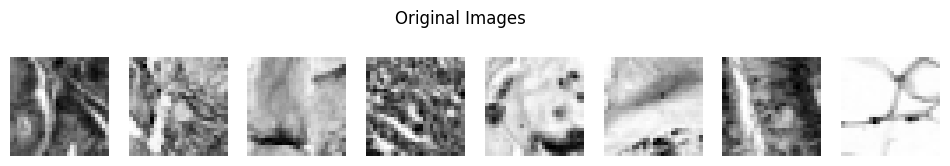

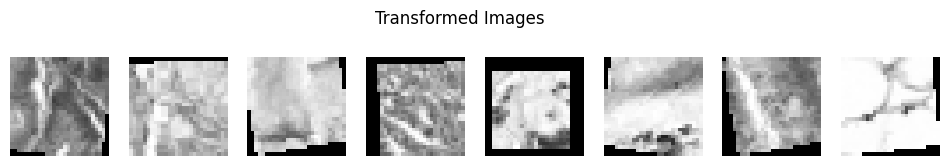

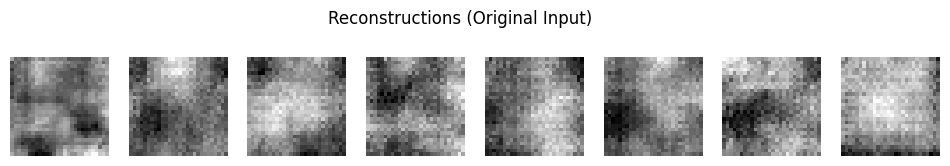

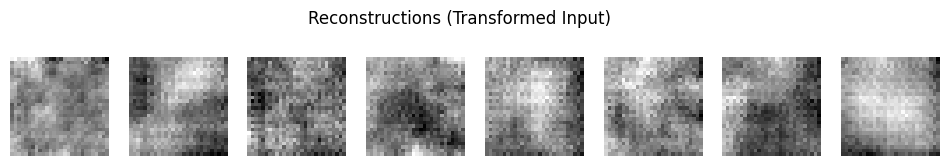

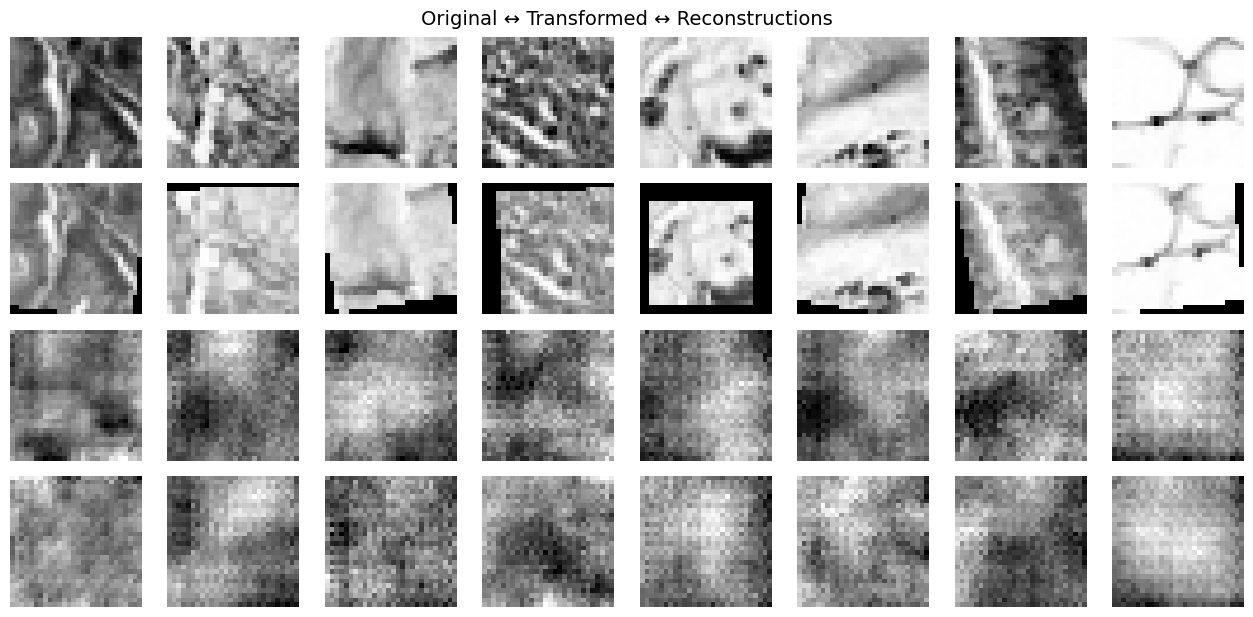

t-SNE on 5120 latent vectors


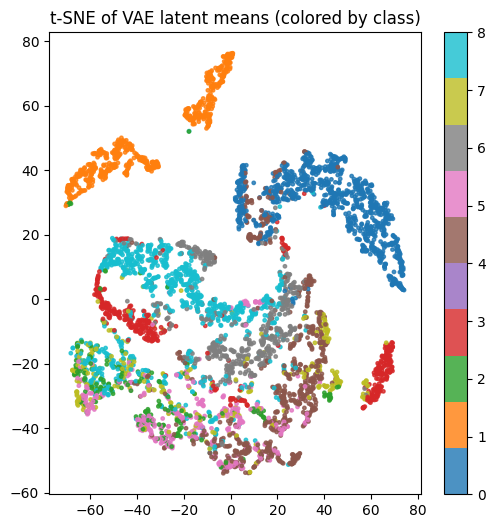

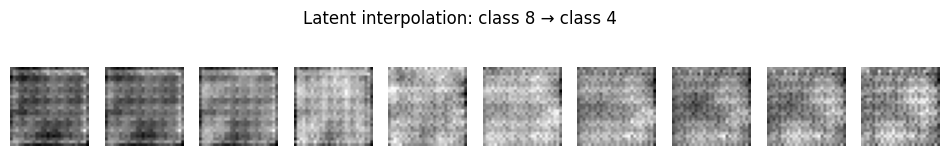

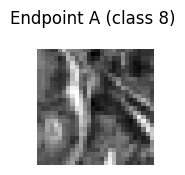

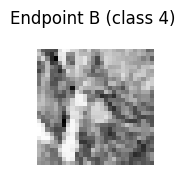

All visualizations complete.


In [11]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from torchvision import transforms
from torchvision.transforms import functional as TF

# Save models directly to the root of the mounted drive, if os.makedirs for nested directories is not supported
# If you require a 'checkpoints' directory, please create it manually in Google Drive.
if DATASET.lower() == "fashion":
  vae_save_path = "/content/drive/MyDrive/vae_fashion_final.pth"
  clf_save_path = "/content/drive/MyDrive/classifier_fashion_final.pth"
elif DATASET.lower() == "medmnist":
  vae_save_path = "/content/drive/MyDrive/vae_medmnist_final.pth"
  clf_save_path = "/content/drive/MyDrive/classifier_medmnist_final.pth"
else: ## default to "mnist"
  vae_save_path = "/content/drive/MyDrive/vae_mnist_final.pth"
  clf_save_path = "/content/drive/MyDrive/classifier_mnist_final.pth"

torch.save(vae.state_dict(), vae_save_path)
torch.save(clf.state_dict(), clf_save_path)
print(f"Saved: {vae_save_path} and {clf_save_path}")

# ------------------------------------------------
# Helper: apply the same kind of random affine used in training
# ------------------------------------------------
rand_affine = transforms.RandomAffine(degrees=10, translate=(4/IMG_SIZE, 4/IMG_SIZE), scale=(0.8, 1.2))

# fetch a small batch from test_loader
vae.eval()
with torch.no_grad():
    imgs_batch, labels_batch = next(iter(test_loader))
    imgs_batch = imgs_batch.to(DEVICE)
    labels_batch = labels_batch.to(DEVICE)

# create transformed batch (apply PIL-based RandomAffine to each image)
to_pil = transforms.ToPILImage()
to_tensor = transforms.ToTensor()
n_show = min(8, imgs_batch.size(0))
transformed = []
for i in range(n_show):
    pil = to_pil(imgs_batch[i].cpu())
    pil_t = rand_affine(pil)
    transformed.append(to_tensor(pil_t))
transformed = torch.stack(transformed).to(DEVICE)

# get reconstructions for original and transformed
with torch.no_grad():
    recon_orig, mu_orig, logvar_orig = vae(imgs_batch[:n_show])
    recon_trans, mu_trans, logvar_trans = vae(transformed)

# Helper plot function (single-row display)
def show_row(tensor_batch, title="", n=n_show):
    arr = tensor_batch[:n].cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 2))
    # Handle case where n=1, as plt.subplots returns a single Axes object, not an array
    if n == 1:
        ax = axes
        ax.imshow(arr[0, 0], cmap="gray")
        ax.axis("off")
    else:
        for i, ax in enumerate(axes):
            ax.imshow(arr[i, 0], cmap="gray")
            ax.axis("off")
    plt.suptitle(title)
    plt.show()

# show originals / transformed / recons
show_row(imgs_batch, "Original Images")
show_row(transformed, "Transformed Images")
show_row(recon_orig, "Reconstructions (Original Input)")
show_row(recon_trans, "Reconstructions (Transformed Input)")

# ------------------------------------------------
# Side-by-side composite: 4 rows x n_show columns
# ------------------------------------------------
orig_np = imgs_batch[:n_show].cpu().numpy()
trans_np = transformed[:n_show].cpu().numpy()
recon_o_np = recon_orig[:n_show].cpu().numpy()
recon_t_np = recon_trans[:n_show].cpu().numpy()

fig, axes = plt.subplots(4, n_show, figsize=(1.6*n_show, 6))
rows = [orig_np, trans_np, recon_o_np, recon_t_np]
row_titles = ["Original", "Transformed", "Recon(Orig)", "Recon(Trans)"]
for r, imgs in enumerate(rows):
    for c in range(n_show):
        ax = axes[r, c]
        ax.imshow(imgs[c, 0], cmap="gray")
        ax.axis("off")
        if c == 0:
            ax.set_ylabel(row_titles[r], fontsize=10, rotation=0, labelpad=40, va="center")
plt.tight_layout()
plt.suptitle("Original ↔ Transformed ↔ Reconstructions", y=1.02, fontsize=14)
plt.show()

# ------------------------------------------------
# Latent t-SNE visualization (using encoder means)
# ------------------------------------------------
def collect_latents(loader, max_batches=None):
    zs = []
    ys = []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.to(DEVICE)
            mu, _ = vae.enc(x)
            zs.append(mu.cpu().numpy())
            ys.append(y.numpy())
            if max_batches and i+1 >= max_batches:
                break
    return np.vstack(zs), np.concatenate(ys)

# collect latents from test set (limit to keep t-SNE faster)
latents, labels = collect_latents(test_loader, max_batches=20)  # ~20 * batch_size samples
print(f"t-SNE on {latents.shape[0]} latent vectors")
latents_2d = TSNE(n_components=2, random_state=42, init='pca', perplexity=30).fit_transform(latents)

plt.figure(figsize=(6,6))
sc = plt.scatter(latents_2d[:,0], latents_2d[:,1], c=labels, cmap="tab10", s=6, alpha=0.8)
plt.title("t-SNE of VAE latent means (colored by class)")
plt.colorbar(sc)
plt.show()

# ------------------------------------------------
# Latent interpolation between TWO test images from different classes (Option B)
# ------------------------------------------------
# Find two images from different classes in test_loader
img_a = img_b = None
label_a = label_b = None

for imgs, labs in test_loader:
    for i in range(imgs.size(0)):
        for j in range(i+1, imgs.size(0)):
            if labs[i].item() != labs[j].item():
                img_a = imgs[i].unsqueeze(0).to(DEVICE)
                label_a = labs[i].item()
                img_b = imgs[j].unsqueeze(0).to(DEVICE)
                label_b = labs[j].item()
                break
        if img_a is not None:
            break
    if img_a is not None:
        break

if img_a is None:
    raise RuntimeError("Could not find two different-class samples in test_loader.")

# encode to latent means
vae.eval()
with torch.no_grad():
    mu_a, _ = vae.enc(img_a)
    mu_b, _ = vae.enc(img_b)

# interpolate in latent space
n_steps = 10
alphas = np.linspace(0, 1, n_steps)
interp_z = torch.stack([torch.from_numpy(((1 - a) * mu_a.cpu().numpy() + a * mu_b.cpu().numpy()).squeeze()).float() for a in alphas]).to(DEVICE)

# decode interpolations
with torch.no_grad():
    recon_interp = vae.dec(interp_z).cpu().numpy()  # shape (n_steps, 1, H, W)

# show interpolation grid
fig, axes = plt.subplots(1, n_steps, figsize=(n_steps*1.2, 2))
for i in range(n_steps):
    axes[i].imshow(recon_interp[i,0], cmap="gray")
    axes[i].axis("off")
plt.suptitle(f"Latent interpolation: class {label_a} → class {label_b}", fontsize=12)
plt.show()

# also show the endpoints (original images) for clarity
show_row(img_a, f"Endpoint A (class {label_a})", n=1)
show_row(img_b, f"Endpoint B (class {label_b})", n=1)

print("All visualizations complete.")

# VISUAL REPORT: Testing invariance to small transformations

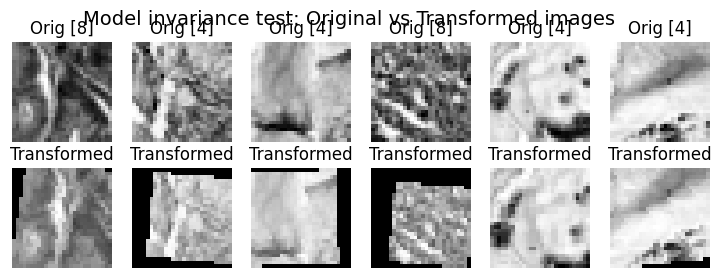

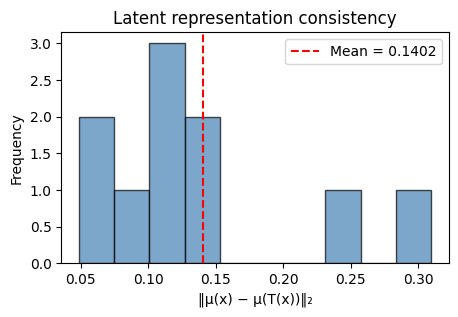

✅ Average latent-space distance under small transforms: 0.1402
Lower = better invariance. Values << 1 suggest good stability.


In [13]:
# ============================================================
# VISUAL REPORT: Testing invariance to small transformations
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

vae.eval()

# Define the random transform within the invariance range
test_transform = transforms.RandomAffine(
    degrees=10, translate=(4/IMG_SIZE, 4/IMG_SIZE), scale=(0.8, 1.2)
)
to_pil = transforms.ToPILImage()
to_tensor = transforms.ToTensor()

# Pick a small random subset from the test data
n_samples = 10
imgs, labels = next(iter(test_loader))
imgs = imgs[:n_samples].to(DEVICE)
labels = labels[:n_samples]

# Apply transforms
trans_imgs = []
for im in imgs.cpu():
    pil = to_pil(im)
    pil_t = test_transform(pil)
    trans_imgs.append(to_tensor(pil_t))
trans_imgs = torch.stack(trans_imgs).to(DEVICE)

# Encode both sets and compute mean latent distance
with torch.no_grad():
    mu_x, _ = vae.enc(imgs)
    mu_tx, _ = vae.enc(trans_imgs)

latent_dists = torch.norm(mu_x - mu_tx, dim=1).cpu().numpy()
avg_dist = latent_dists.mean()

# ------------------------------------------------------------
# Visualize examples and quantitative summary
# ------------------------------------------------------------
n_show = min(6, n_samples)
fig, axes = plt.subplots(2, n_show, figsize=(1.5*n_show, 3))
for i in range(n_show):
    axes[0,i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
    axes[0,i].set_title(f"Orig [{labels[i].item()}]")
    axes[1,i].imshow(trans_imgs[i].cpu().squeeze(), cmap='gray')
    axes[1,i].set_title("Transformed")
    axes[0,i].axis('off'); axes[1,i].axis('off')
plt.suptitle("Model invariance test: Original vs Transformed images", fontsize=14)
plt.show()

# Plot histogram of latent distances
plt.figure(figsize=(5,3))
plt.hist(latent_dists, bins=10, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(avg_dist, color='red', linestyle='--', label=f"Mean = {avg_dist:.4f}")
plt.xlabel("‖μ(x) − μ(T(x))‖₂")
plt.ylabel("Frequency")
plt.legend()
plt.title("Latent representation consistency")
plt.show()

print(f"✅ Average latent-space distance under small transforms: {avg_dist:.4f}")
print("Lower = better invariance. Values << 1 suggest good stability.")

here is an extended invariance-testing cell that separates the analysis into:

✅ Rotation-only invariance

✅ Scale-only invariance

✅ Translation-only invariance

✅ Combined invariance (the earlier test)

For each transformation type, it:


*   Applies a controlled transform
*   Encodes both original and transformed images
*   Computes latent distance

Plots:

*   original vs transformed images

*   histogram of latent distances

*   Prints mean distance for each category

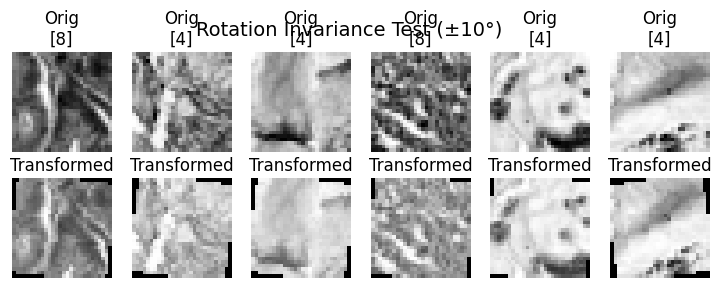

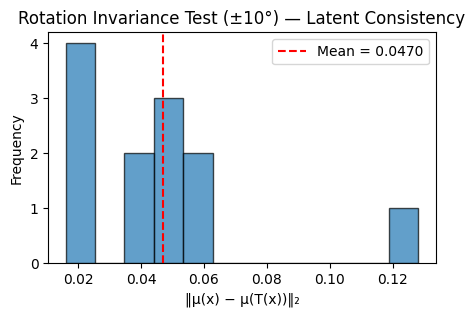

🔹 Rotation Invariance Test (±10°): mean latent distance = 0.0470



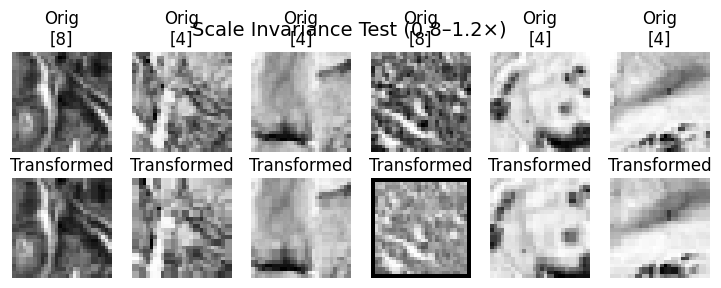

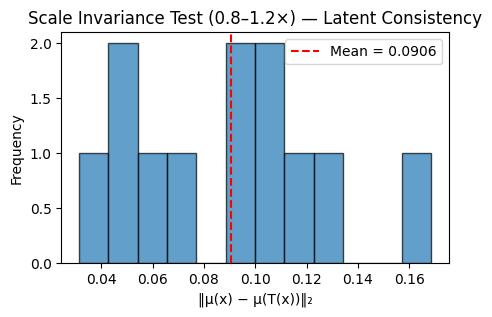

🔹 Scale Invariance Test (0.8–1.2×): mean latent distance = 0.0906



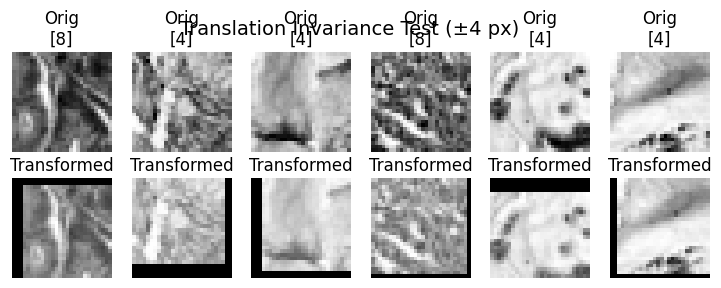

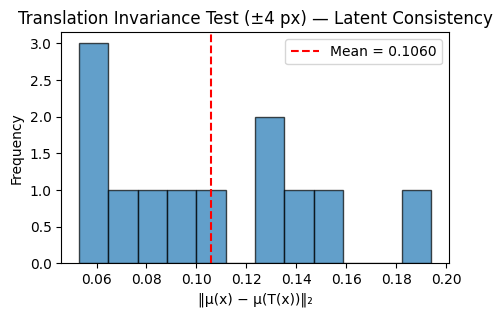

🔹 Translation Invariance Test (±4 px): mean latent distance = 0.1060



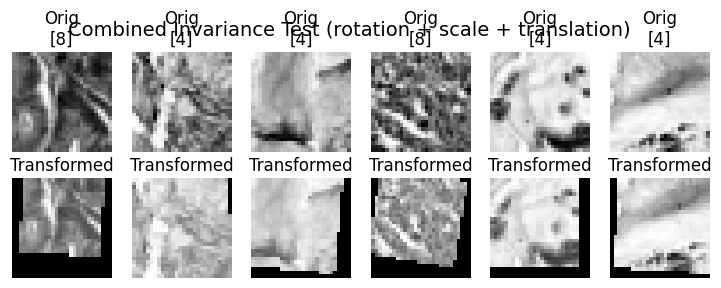

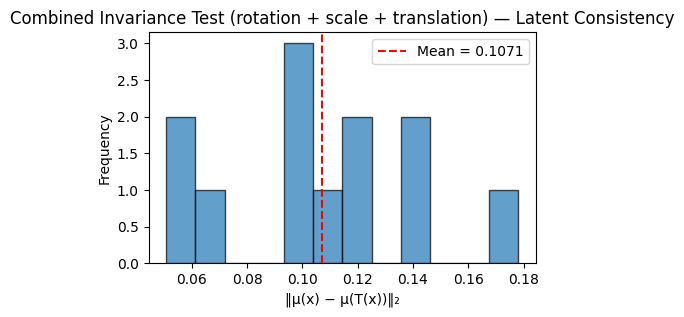

🔹 Combined Invariance Test (rotation + scale + translation): mean latent distance = 0.1071

           INVARIANCE SUMMARY — LATENT DISTANCES     
 Rotation-only:     0.0470
 Scale-only:        0.0906
 Translation-only:  0.1060
 Combined:          0.1071
Lower = stronger invariance.



In [14]:
# =====================================================================
# EXTENDED INVARIANCE REPORT
# Tests invariance to:
#   1) Rotations (±10°)
#   2) Scalings (0.8–1.2×)
#   3) Translations (±4 px)
#   4) Combined transforms
# =====================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

vae.eval()

to_pil = transforms.ToPILImage()
to_tensor = transforms.ToTensor()

# Boundaries
ROT_DEG = 10
SCALE_RANGE = (0.8, 1.2)
TRANS_PIX = 4 / IMG_SIZE

# Get a fixed mini-batch
n_samples = 12
imgs, labels = next(iter(test_loader))
imgs = imgs[:n_samples].to(DEVICE)
labels = labels[:n_samples]

# ------------------------------------------------------------
# Helper to compute latent distance for a transform
# ------------------------------------------------------------
def test_invariance(transform, title, n_show=6, bins=12):

    # Apply transform
    transformed = []
    for im in imgs.cpu():
        pil = to_pil(im)
        pil_t = transform(pil)
        transformed.append(to_tensor(pil_t))
    transformed = torch.stack(transformed).to(DEVICE)

    # Encode both
    with torch.no_grad():
        mu_x, _ = vae.enc(imgs)
        mu_t, _ = vae.enc(transformed)

    # Distances
    dists = torch.norm(mu_x - mu_t, dim=1).cpu().numpy()
    avg = dists.mean()

    # ------------------------------------------------------------
    # Plot original vs transformed samples
    # ------------------------------------------------------------
    n_show = min(n_show, n_samples)
    fig, axes = plt.subplots(2, n_show, figsize=(1.5*n_show, 3))
    for i in range(n_show):
        axes[0,i].imshow(imgs[i].cpu().squeeze(), cmap='gray')
        axes[0,i].set_title(f"Orig\n[{labels[i].item()}]")
        axes[1,i].imshow(transformed[i].cpu().squeeze(), cmap='gray')
        axes[1,i].set_title("Transformed")
        axes[0,i].axis('off'); axes[1,i].axis('off')
    plt.suptitle(title, fontsize=14)
    plt.show()

    # ------------------------------------------------------------
    # Histogram of latent-space distances
    # ------------------------------------------------------------
    plt.figure(figsize=(5,3))
    plt.hist(dists, bins=bins, edgecolor='black', alpha=0.7)
    plt.axvline(avg, color='red', linestyle='--', label=f"Mean = {avg:.4f}")
    plt.xlabel("‖μ(x) − μ(T(x))‖₂")
    plt.ylabel("Frequency")
    plt.title(title + " — Latent Consistency")
    plt.legend()
    plt.show()

    print(f"🔹 {title}: mean latent distance = {avg:.4f}\n")
    return avg


# ============================================================
# 1) Rotation-only invariance
# ============================================================
rot_transform = transforms.RandomRotation(degrees=ROT_DEG)
avg_rot = test_invariance(rot_transform, "Rotation Invariance Test (±10°)")


# ============================================================
# 2) Scale-only invariance
# ============================================================
scale_transform = transforms.RandomAffine(
    degrees=0, scale=SCALE_RANGE
)
avg_scale = test_invariance(scale_transform, "Scale Invariance Test (0.8–1.2×)")


# ============================================================
# 3) Translation-only invariance
# ============================================================
translate_transform = transforms.RandomAffine(
    degrees=0, translate=(TRANS_PIX, TRANS_PIX)
)
avg_trans = test_invariance(translate_transform, "Translation Invariance Test (±4 px)")


# ============================================================
# 4) Combined transform invariance
# ============================================================
combined_transform = transforms.RandomAffine(
    degrees=ROT_DEG,
    translate=(TRANS_PIX, TRANS_PIX),
    scale=SCALE_RANGE
)
avg_combined = test_invariance(
    combined_transform,
    "Combined Invariance Test (rotation + scale + translation)"
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("====================================================")
print("           INVARIANCE SUMMARY — LATENT DISTANCES     ")
print("====================================================")
print(f" Rotation-only:     {avg_rot:.4f}")
print(f" Scale-only:        {avg_scale:.4f}")
print(f" Translation-only:  {avg_trans:.4f}")
print(f" Combined:          {avg_combined:.4f}")
print("Lower = stronger invariance.\n")

Below is a dedicated heatmap cell that computes per-latent-dimension sensitivity to each transformation type:

*   Rotation (±10°)

*   Scaling (0.8–1.2×)

*   Translation (±4 px)

*   Combined transform

It then builds a latent sensitivity matrix shaped:

**(latent_dim) × (4 transform types)**

and plots it as a heatmap.

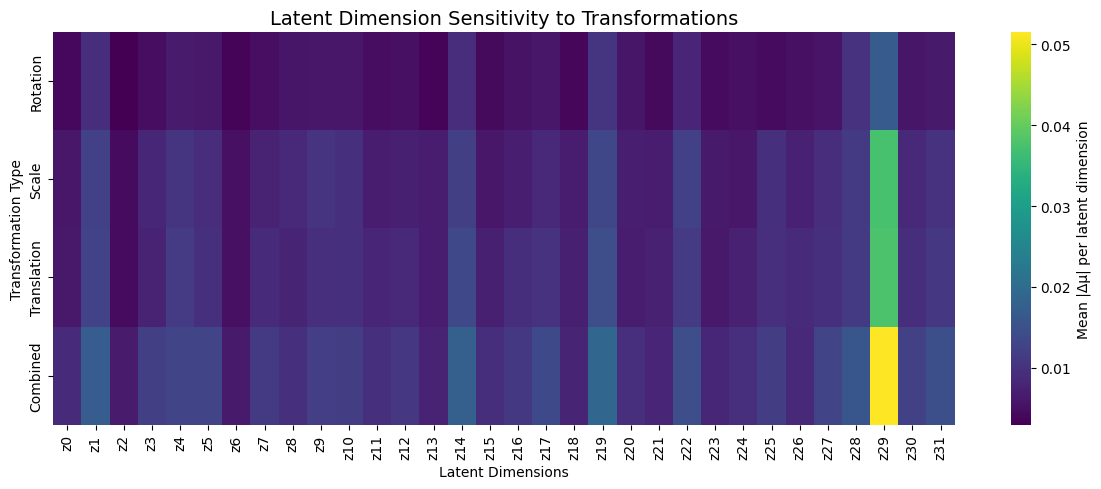

In [15]:
# =====================================================================
# LATENT DIMENSION TRANSFORMATION SENSITIVITY HEATMAP
# =====================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import seaborn as sns

vae.eval()

# ------------------------------
# Transformation configs
# ------------------------------
ROT_DEG = 10
SCALE_RANGE = (0.8, 1.2)
TRANS_PIX = 4 / IMG_SIZE

# Transform definitions
transforms_dict = {
    "Rotation": transforms.RandomRotation(degrees=ROT_DEG),
    "Scale": transforms.RandomAffine(degrees=0, scale=SCALE_RANGE),
    "Translation": transforms.RandomAffine(degrees=0, translate=(TRANS_PIX, TRANS_PIX)),
    "Combined": transforms.RandomAffine(
        degrees=ROT_DEG,
        translate=(TRANS_PIX, TRANS_PIX),
        scale=SCALE_RANGE
    )
}

to_pil = transforms.ToPILImage()
to_tensor = transforms.ToTensor()

# ------------------------------
# Load a moderately-sized batch
# ------------------------------
imgs, _ = next(iter(test_loader))
imgs = imgs[:64].to(DEVICE)   # Use 64 samples for stable stats

with torch.no_grad():
    mu_base, _ = vae.enc(imgs)     # (batch, latent_dim)

latent_dim = mu_base.shape[1]
sens_matrix = []

# ------------------------------
# Sensitivity computation
# ------------------------------
for name, tf in transforms_dict.items():
    transformed = []

    for im in imgs.cpu():
        pil = to_pil(im)
        pil_t = tf(pil)
        transformed.append(to_tensor(pil_t))
    transformed = torch.stack(transformed).to(DEVICE)

    with torch.no_grad():
        mu_tf, _ = vae.enc(transformed)

    # Per-dimension absolute difference
    per_dim_sensitivity = torch.mean(torch.abs(mu_base - mu_tf), dim=0).cpu().numpy()
    sens_matrix.append(per_dim_sensitivity)

# (4 transforms × latent_dim)
sens_matrix = np.array(sens_matrix)

# ------------------------------
# Plot Heatmap
# ------------------------------
plt.figure(figsize=(12, 5))
sns.heatmap(
    sens_matrix,
    cmap="viridis",
    xticklabels=[f"z{i}" for i in range(latent_dim)],
    yticklabels=list(transforms_dict.keys()),
    cbar_kws={'label': 'Mean |Δμ| per latent dimension'}
)
plt.title("Latent Dimension Sensitivity to Transformations", fontsize=14)
plt.xlabel("Latent Dimensions")
plt.ylabel("Transformation Type")
plt.tight_layout()
plt.show()


***🕸️ Radar Plots for Comparing Transformations (New Cell)***

Below is a stand-alone radar-plot.

It will generate a radar chart for each transformation type, showing which latent dimensions change the most.

This makes it easy to visually compare the shape of sensitivity profiles across transformations.

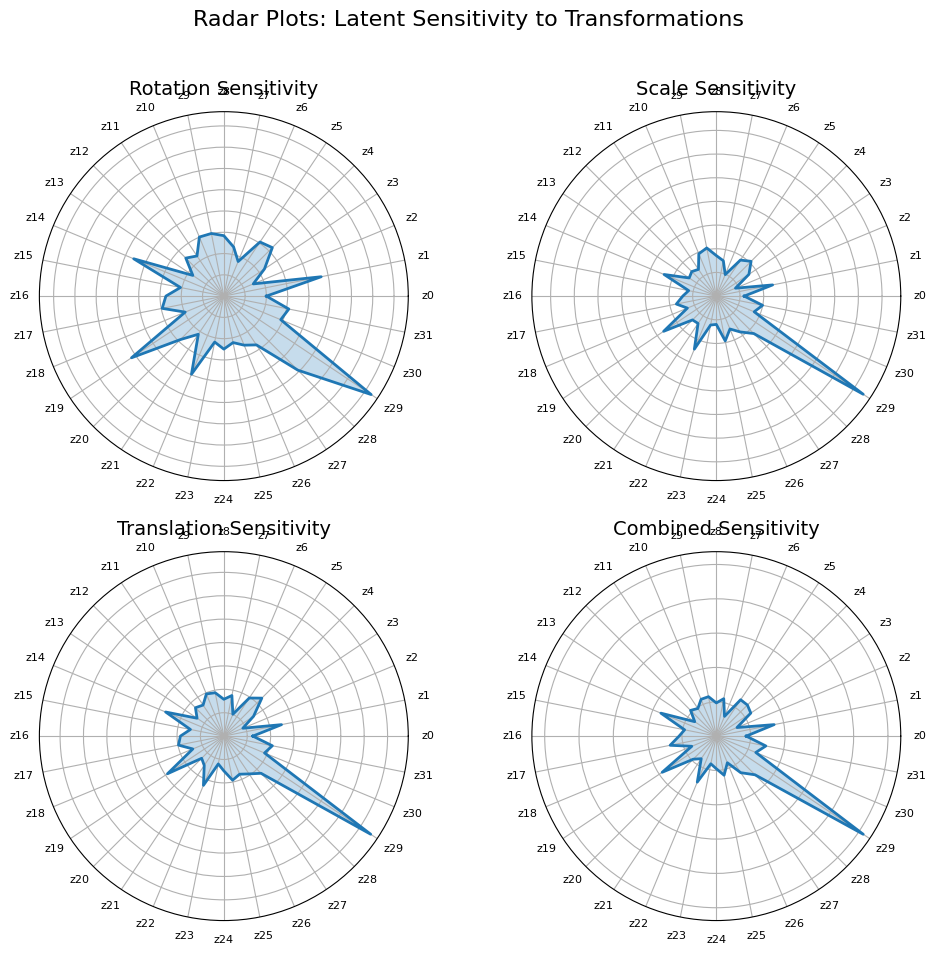

In [16]:
# =====================================================================
# RADAR PLOTS — LATENT DIMENSION SENSITIVITY PER TRANSFORMATION
# Uses the sensitivity matrix computed earlier.
# Requires: sens_matrix (4 × latent_dim) and transforms_dict.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

# Ensure we have sens_matrix and transforms_dict from earlier
assert 'sens_matrix' in globals(), "Run the sensitivity heatmap cell first."

transform_names = list(transforms_dict.keys())
num_transforms, latent_dim = sens_matrix.shape

# Angles for radar chart
angles = np.linspace(0, 2 * np.pi, latent_dim, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Create figure
plt.figure(figsize=(10, 10))

for i, name in enumerate(transform_names):
    values = sens_matrix[i].tolist()
    values += values[:1]  # close loop

    ax = plt.subplot(2, 2, i+1, polar=True)
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

    ax.set_title(f"{name} Sensitivity", fontsize=14, pad=12)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f"z{k}" for k in range(latent_dim)], fontsize=8)
    ax.set_yticklabels([])  # cleaner look

plt.suptitle("Radar Plots: Latent Sensitivity to Transformations", fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


# Conclusions

Here’s a compact “visual + numerical invariance test” cell you can paste near the end of your notebook (after training and visualizations). It evaluates how stable the latent representation μ(x) is under random small transformations
𝑇(𝑥) T(x).

It does three things:

1.   Randomly samples test images.
2.   Applies a set of random affine transforms within your target invariance bounds (±10° rotation, ±20% scale, ±4 px translation).
3.   Plots the original vs transformed images, plus reports the average L2 distance between latent means — i.e.



latent_distance = 𝐸∥𝜇(𝑥)−𝜇(𝑇(𝑥))∥2

Lower values ⇒ stronger invariance.